In [2]:
# Basic CNN Training for APTOS Retinal Classification
# This notebook uses pre-split train/val folders from the dataset.
# It trains a basic CNN model and saves checkpoints and training logs.
# Run cells from top to bottom.

In [3]:
import copy
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from torchvision.datasets.folder import default_loader

import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    )

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
# Training configuration
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
IMAGE_SIZE = 224
HOLDOUT_TEST_RATIO = 0.2
USE_SPLIT_CSV = True

OUTPUT_DIR = Path.cwd() / "basic_cnn_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUTPUT_DIR)
print("Holdout test ratio from train:", HOLDOUT_TEST_RATIO)

# Dataset root resolution
candidate_roots = [
    (Path.cwd() / "../dataset/aptos2019-blindness-detection/imagefolder").resolve(),
    (Path.cwd() / "dataset/aptos2019-blindness-detection/imagefolder").resolve(),
]

DATA_ROOT = next((p for p in candidate_roots if p.exists()), None)
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not find dataset root. Checked: " + ", ".join(str(p) for p in candidate_roots)
    )

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"
SPLITS_DIR = DATA_ROOT / "splits"
TRAIN_SPLIT_CSV = SPLITS_DIR / "train_split.csv"
VAL_SPLIT_CSV = SPLITS_DIR / "val_split.csv"

if not TRAIN_DIR.exists() or not VAL_DIR.exists():
    raise FileNotFoundError("Train/Val directories are required under dataset root.")

print("Dataset root:", DATA_ROOT)
print("Train dir:", TRAIN_DIR)
print("Val dir:", VAL_DIR)
print("Unlabeled test dir:", TEST_DIR)
print("Train split CSV:", TRAIN_SPLIT_CSV)
print("Val split CSV:", VAL_SPLIT_CSV)

Output directory: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/CNN/basic_cnn_outputs
Holdout test ratio from train: 0.2
Dataset root: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/dataset/aptos2019-blindness-detection/imagefolder
Train dir: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/dataset/aptos2019-blindness-detection/imagefolder/train
Val dir: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/dataset/aptos2019-blindness-detection/imagefolder/val
Unlabeled test dir: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/dataset/aptos2019-blindness-detection/imagefolder/test
Train split CSV: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/dataset/aptos2019-blindness-detection/imagefolder/splits/train_split.csv
Val split CSV: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/dataset/aptos2019-blindness-detection/imagefolder/splits/val_split.csv


In [5]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class CSVLabeledDataset(Dataset):
    def __init__(self, entries, transform):
        # entries: List[Tuple[path, label_from_csv]]
        self.entries = list(entries)
        self.transform = transform
        self.samples = self.entries
        self.targets = [int(label) for _, label in self.entries]

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        path, label = self.entries[idx]
        image = default_loader(path)
        if self.transform is not None:
            image = self.transform(image)
        return image, int(label)

class UnlabeledImageDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = list(image_paths)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = default_loader(path)
        if self.transform is not None:
            image = self.transform(image)
        return image, str(path)

def stratified_holdout_indices(targets, holdout_ratio, seed):
    rng = np.random.default_rng(seed)
    class_to_indices = {}
    for idx, label in enumerate(targets):
        class_to_indices.setdefault(label, []).append(idx)

    train_indices = []
    holdout_indices = []

    for label in sorted(class_to_indices.keys()):
        indices = np.array(class_to_indices[label])
        rng.shuffle(indices)
        n_total = len(indices)

        if n_total <= 1:
            n_holdout = 0
        else:
            n_holdout = int(round(n_total * holdout_ratio))
            n_holdout = max(1, n_holdout)
            n_holdout = min(n_holdout, n_total - 1)

        holdout_indices.extend(indices[:n_holdout].tolist())
        train_indices.extend(indices[n_holdout:].tolist())

    rng.shuffle(train_indices)
    rng.shuffle(holdout_indices)
    return train_indices, holdout_indices

def build_id_to_path_map(data_dir):
    image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
    id_to_path = {}
    duplicate_count = 0

    for path in sorted(data_dir.rglob("*")):
        if not path.is_file() or path.suffix.lower() not in image_exts:
            continue
        image_id = path.stem
        if image_id in id_to_path:
            duplicate_count += 1
            continue
        id_to_path[image_id] = str(path)

    if duplicate_count > 0:
        print(f"Warning: {duplicate_count} duplicate image ids in {data_dir}. First occurrence kept.")
    return id_to_path

def entries_from_split_csv(csv_path, id_to_path, split_name, num_classes):
    if not csv_path.exists():
        raise FileNotFoundError(f"{split_name} split CSV not found: {csv_path}")

    split_df = pd.read_csv(csv_path)
    required_cols = {"id_code", "diagnosis"}
    if not required_cols.issubset(split_df.columns):
        raise ValueError(
            f"{split_name} split CSV must contain columns: {sorted(required_cols)}"
        )

    entries = []
    missing_count = 0
    invalid_label_count = 0

    for row in split_df.itertuples(index=False):
        image_id = str(getattr(row, "id_code")).strip()
        csv_label = int(getattr(row, "diagnosis"))

        path = id_to_path.get(image_id)
        if path is None:
            missing_count += 1
            continue

        if csv_label < 0 or csv_label >= num_classes:
            invalid_label_count += 1
            continue

        entries.append((path, csv_label))

    print(
        f"{split_name} split -> rows: {len(split_df)}, matched: {len(entries)}, "
        f"missing: {missing_count}, invalid_label: {invalid_label_count}"
    )

    if len(entries) == 0:
        raise RuntimeError(f"No valid samples found for {split_name} split from CSV.")

    return entries

# Build class vocabulary from train folder structure (0..4).
train_base = datasets.ImageFolder(TRAIN_DIR)
num_classes = len(train_base.classes)
class_names = [str(i) for i in range(num_classes)]

if USE_SPLIT_CSV:
    if not TRAIN_SPLIT_CSV.exists() or not VAL_SPLIT_CSV.exists():
        raise FileNotFoundError(
            "Split CSV files are required but missing. "
            f"Expected: {TRAIN_SPLIT_CSV} and {VAL_SPLIT_CSV}"
        )

    print("Using labels from split CSV files (diagnosis column).")
    train_id_to_path = build_id_to_path_map(TRAIN_DIR)
    val_id_to_path = build_id_to_path_map(VAL_DIR)

    train_entries_full = entries_from_split_csv(
        TRAIN_SPLIT_CSV,
        train_id_to_path,
        "train",
        num_classes,
    )
    val_entries = entries_from_split_csv(
        VAL_SPLIT_CSV,
        val_id_to_path,
        "val",
        num_classes,
    )
else:
    print("USE_SPLIT_CSV is False; falling back to folder labels.")
    train_entries_full = [(path, int(label)) for path, label in train_base.samples]
    val_base = datasets.ImageFolder(VAL_DIR)
    val_entries = [(path, int(label)) for path, label in val_base.samples]

train_labels_full = [label for _, label in train_entries_full]
local_train_indices, local_holdout_indices = stratified_holdout_indices(
    train_labels_full,
    HOLDOUT_TEST_RATIO,
    SEED,
 )

if len(local_train_indices) == 0 or len(local_holdout_indices) == 0:
    raise RuntimeError(
        "Unable to create train/holdout split from train split CSV rows. "
        "Check dataset size and HOLDOUT_TEST_RATIO."
    )

train_entries = [train_entries_full[i] for i in local_train_indices]
holdout_test_entries = [train_entries_full[i] for i in local_holdout_indices]

train_set = CSVLabeledDataset(train_entries, train_transform)
val_set = CSVLabeledDataset(val_entries, eval_transform)
test_set = CSVLabeledDataset(holdout_test_entries, eval_transform)

# Unlabeled competition-style test directory for inference only.
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
unlabeled_test_paths = []
if TEST_DIR.exists():
    unlabeled_test_paths = sorted(
        [p for p in TEST_DIR.rglob("*") if p.is_file() and p.suffix.lower() in image_exts]
    )
unlabeled_test_set = UnlabeledImageDataset(unlabeled_test_paths, transform=eval_transform)

def get_class_counts(ds):
    targets = getattr(ds, "targets", None)
    if targets is None:
        return {}
    counts = Counter(targets)
    return {class_names[i]: counts.get(i, 0) for i in range(num_classes)}

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Train images (after holdout split):", len(train_set))
print("Validation images (from val_split.csv):", len(val_set))
print("Holdout test images (20% from train_split.csv):", len(test_set))
print("Unlabeled test images (from test directory):", len(unlabeled_test_set))

print("\nClass distribution (train):", get_class_counts(train_set))
print("Class distribution (val):", get_class_counts(val_set))
print("Class distribution (holdout test):", get_class_counts(test_set))

Using labels from split CSV files (diagnosis column).
train split -> rows: 2929, matched: 2929, missing: 0, invalid_label: 0
val split -> rows: 733, matched: 733, missing: 0, invalid_label: 0
Classes: ['0', '1', '2', '3', '4']
Number of classes: 5
Train images (after holdout split): 2343
Validation images (from val_split.csv): 733
Holdout test images (20% from train_split.csv): 586
Unlabeled test images (from test directory): 1928

Class distribution (train): {'0': 1155, '1': 237, '2': 639, '3': 123, '4': 189}
Class distribution (val): {'0': 361, '1': 74, '2': 200, '3': 39, '4': 59}
Class distribution (holdout test): {'0': 289, '1': 59, '2': 160, '3': 31, '4': 47}


In [6]:
# DataLoaders
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
)

# This test loader uses 20% holdout sampled from train_split.csv (CSV labels).
test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
    drop_last=False,
)

# Unlabeled test loader for inference only (no metrics possible).
unlabeled_test_loader = None
if len(unlabeled_test_set) > 0:
    unlabeled_test_loader = DataLoader(
        unlabeled_test_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        drop_last=False,
    )

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Holdout test batches:", len(test_loader))
print(
    "Unlabeled test batches:",
    len(unlabeled_test_loader) if unlabeled_test_loader is not None else 0,
    )

Train batches: 74
Val batches: 23
Holdout test batches: 19
Unlabeled test batches: 61


In [7]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model = BasicCNN(num_classes=num_classes).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Li

In [8]:
def compute_prf_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    return float(precision), float(recall), float(f1)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        preds = outputs.argmax(dim=1)
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_samples += batch_size

        y_true.extend(labels.detach().cpu().numpy().tolist())
        y_pred.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / max(total_samples, 1)
    avg_acc = 100.0 * total_correct / max(total_samples, 1)
    return avg_loss, avg_acc, y_true, y_pred

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler_kwargs = {
    "mode": "min",
    "factor": 0.5,
    "patience": 3,
}

# Keep compatibility across torch versions where `verbose` may not exist.
try:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        verbose=True,
        **scheduler_kwargs,
    )
except TypeError:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        **scheduler_kwargs,
    )

In [10]:


best_val_acc = -1.0
best_epoch = -1
best_weights = copy.deepcopy(model.state_dict())
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc, train_true, train_pred = run_epoch(
        model, train_loader, criterion, optimizer=optimizer
    )
    val_loss, val_acc, val_true, val_pred = run_epoch(
        model, val_loader, criterion, optimizer=None
    )

    train_precision, train_recall, train_f1 = compute_prf_metrics(train_true, train_pred)
    val_precision, val_recall, val_f1 = compute_prf_metrics(val_true, val_pred)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_precision": train_precision,
        "train_recall": train_recall,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_precision": val_precision,
        "val_recall": val_recall,
        "val_f1": val_f1,
        "lr": current_lr,
    })

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Train P/R/F1: {train_precision:.4f}/{train_recall:.4f}/{train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
        f"Val P/R/F1: {val_precision:.4f}/{val_recall:.4f}/{val_f1:.4f} | "
        f"LR: {current_lr:.6f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_weights = copy.deepcopy(model.state_dict())

model.load_state_dict(best_weights)
print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

Epoch 01/50 | Train Loss: 1.1498 | Train Acc: 56.81% | Train P/R/F1: 0.4434/0.5681/0.4906 | Val Loss: 1.0839 | Val Acc: 55.80% | Val P/R/F1: 0.4112/0.5580/0.4597 | LR: 0.001000
Epoch 02/50 | Train Loss: 0.9368 | Train Acc: 67.22% | Train P/R/F1: 0.6065/0.6722/0.5942 | Val Loss: 0.9154 | Val Acc: 69.30% | Val P/R/F1: 0.6304/0.6930/0.6230 | LR: 0.001000
Epoch 03/50 | Train Loss: 0.8791 | Train Acc: 69.78% | Train P/R/F1: 0.6020/0.6978/0.6308 | Val Loss: 1.0678 | Val Acc: 62.48% | Val P/R/F1: 0.5910/0.6248/0.5709 | LR: 0.001000
Epoch 04/50 | Train Loss: 0.8599 | Train Acc: 70.25% | Train P/R/F1: 0.6050/0.7025/0.6249 | Val Loss: 1.0456 | Val Acc: 65.21% | Val P/R/F1: 0.5910/0.6521/0.5976 | LR: 0.001000
Epoch 05/50 | Train Loss: 0.8528 | Train Acc: 70.72% | Train P/R/F1: 0.6076/0.7072/0.6307 | Val Loss: 0.9127 | Val Acc: 69.30% | Val P/R/F1: 0.5863/0.6930/0.6295 | LR: 0.001000
Epoch 06/50 | Train Loss: 0.8261 | Train Acc: 71.36% | Train P/R/F1: 0.6254/0.7136/0.6437 | Val Loss: 1.3521 | Val 

In [11]:
# Save checkpoints and logs
best_model_path = OUTPUT_DIR / "basic_cnn_best.pth"
last_model_path = OUTPUT_DIR / "basic_cnn_last.pth"
log_csv_path = OUTPUT_DIR / "training_log.csv"

torch.save(best_weights, best_model_path)
torch.save(model.state_dict(), last_model_path)

history_df = pd.DataFrame(history)
history_df.to_csv(log_csv_path, index=False)

print("Best model saved to:", best_model_path)
print("Last model saved to:", last_model_path)
print("Training log saved to:", log_csv_path)
history_df.tail()

Best model saved to: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/CNN/basic_cnn_outputs/basic_cnn_best.pth
Last model saved to: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/CNN/basic_cnn_outputs/basic_cnn_last.pth
Training log saved to: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/CNN/basic_cnn_outputs/training_log.csv


,epoch,train_loss,train_acc,train_precision,train_recall,train_f1,val_loss,val_acc,val_precision,val_recall,val_f1,lr
45,46,0.686255,75.330773,0.722889,0.753308,0.697197,0.681120,73.806276,0.702228,0.738063,0.672714,0.000125
46,47,0.679312,75.117371,0.669531,0.751174,0.696043,0.682622,74.215553,0.693877,0.742156,0.687626,0.000125
47,48,0.671945,75.032010,0.703897,0.750320,0.694715,0.674612,74.897681,0.702511,0.748977,0.700011,0.000125
48,49,0.670516,75.458813,0.698401,0.754588,0.700813,0.678799,74.624829,0.707957,0.746248,0.695954,0.000125
49,50,0.673754,75.202732,0.698554,0.752027,0.695838,0.667005,75.443383,0.700736,0.754434,0.708793,0.000125


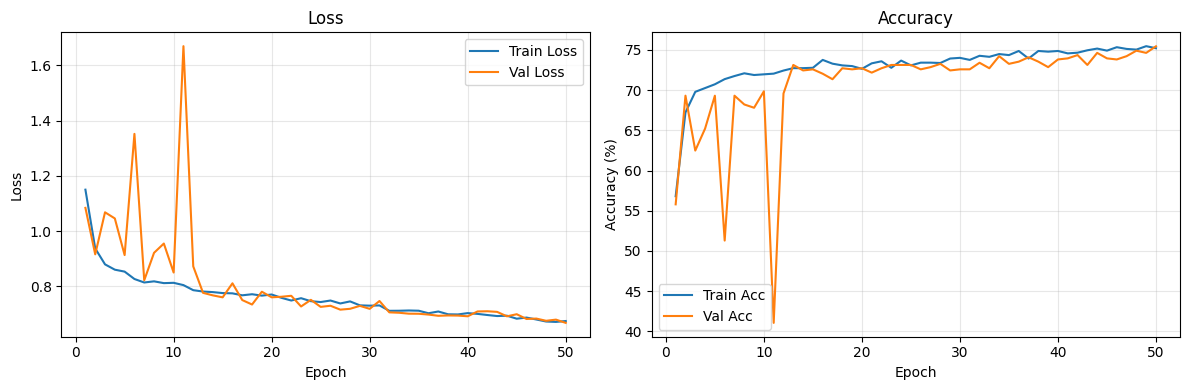

Training curves saved to: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/CNN/basic_cnn_outputs/training_curves.png


In [12]:
# Plot training curves
if history_df.empty:
    raise RuntimeError("History is empty. Run the training cell first.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train Acc")
axes[1].plot(history_df["epoch"], history_df["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
curve_path = OUTPUT_DIR / "training_curves.png"
plt.savefig(curve_path, dpi=200)
plt.show()

print("Training curves saved to:", curve_path)


Split-wise metrics
split     loss  accuracy  precision   recall  f1_score
train 0.632180 76.440461   0.723143 0.764405  0.714604
  val 0.667005 75.443383   0.700736 0.754434  0.708793
 test 0.698463 72.696246   0.643405 0.726962  0.675741
Saved split metrics to: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/CNN/basic_cnn_outputs/split_metrics.csv

TRAIN classification report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1155
           1       0.61      0.42      0.50       237
           2       0.58      0.88      0.70       639
           3       0.80      0.03      0.06       123
           4       0.00      0.00      0.00       189

    accuracy                           0.76      2343
   macro avg       0.59      0.46      0.44      2343
weighted avg       0.72      0.76      0.71      2343

Saved train report to: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/CNN/basic_cnn_outputs/train_classi

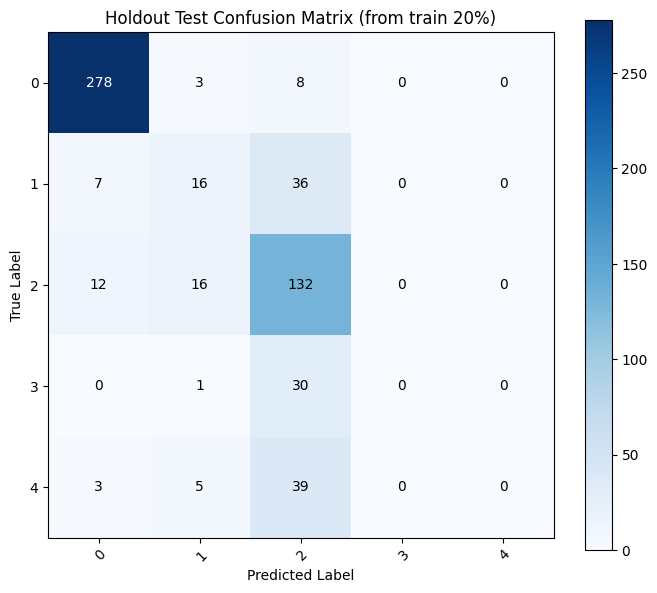

Saved test confusion matrix image to: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/CNN/basic_cnn_outputs/test_confusion_matrix.png

Saved unlabeled test predictions to: /media/aejaz/New Volume/Projects/SNN/Retinal Classification/CNN/basic_cnn_outputs/unlabeled_test_predictions.csv
                                                                                                                         image_path  predicted_class_index predicted_class_name  confidence
/media/aejaz/New Volume/Projects/SNN/Retinal Classification/dataset/aptos2019-blindness-detection/imagefolder/test/0005cfc8afb6.png                      2                    2    0.492677
/media/aejaz/New Volume/Projects/SNN/Retinal Classification/dataset/aptos2019-blindness-detection/imagefolder/test/003f0afdcd15.png                      2                    2    0.654753
/media/aejaz/New Volume/Projects/SNN/Retinal Classification/dataset/aptos2019-blindness-detection/imagefolder/test/006efc72b638.png        

In [13]:
def evaluate_split(split_name, loader):
    loss, acc, y_true, y_pred = run_epoch(model, loader, criterion, optimizer=None)
    precision, recall, f1 = compute_prf_metrics(y_true, y_pred)
    metrics = {
        "split": split_name,
        "loss": float(loss),
        "accuracy": float(acc),
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    }
    return metrics, y_true, y_pred

split_results = []
split_predictions = {}

for split_name, loader in [("train", train_loader), ("val", val_loader), ("test", test_loader)]:
    metrics, y_true, y_pred = evaluate_split(split_name, loader)
    split_results.append(metrics)
    split_predictions[split_name] = (y_true, y_pred)

split_metrics_df = pd.DataFrame(split_results)
print("\nSplit-wise metrics")
print(split_metrics_df.to_string(index=False))

split_metrics_path = OUTPUT_DIR / "split_metrics.csv"
split_metrics_df.to_csv(split_metrics_path, index=False)
print("Saved split metrics to:", split_metrics_path)

for split_name, (y_true, y_pred) in split_predictions.items():
    print(f"\n{split_name.upper()} classification report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    report_df = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).transpose()
    report_path = OUTPUT_DIR / f"{split_name}_classification_report.csv"
    report_df.to_csv(report_path)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_path = OUTPUT_DIR / f"{split_name}_confusion_matrix.csv"
    cm_df.to_csv(cm_path)

    print(f"Saved {split_name} report to:", report_path)
    print(f"Saved {split_name} confusion matrix to:", cm_path)

    if split_name == "test":
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
        ax.figure.colorbar(im, ax=ax)
        ax.set(
            xticks=np.arange(num_classes),
            yticks=np.arange(num_classes),
            xticklabels=class_names,
            yticklabels=class_names,
            title="Holdout Test Confusion Matrix (from train 20%)",
            ylabel="True Label",
            xlabel="Predicted Label",
        )
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        threshold = cm.max() / 2.0 if cm.size else 0.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j,
                    i,
                    format(cm[i, j], "d"),
                    ha="center",
                    va="center",
                    color="white" if cm[i, j] > threshold else "black",
                )

        plt.tight_layout()
        cm_img_path = OUTPUT_DIR / "test_confusion_matrix.png"
        plt.savefig(cm_img_path, dpi=200)
        plt.show()
        plt.close(fig)
        print("Saved test confusion matrix image to:", cm_img_path)

# Inference on unlabeled images from TEST_DIR (no metrics available).
if unlabeled_test_loader is not None:
    model.eval()
    prediction_rows = []

    with torch.no_grad():
        for images, image_paths in unlabeled_test_loader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            probs = torch.softmax(logits, dim=1)
            confidences, pred_indices = torch.max(probs, dim=1)

            for image_path, pred_idx, confidence in zip(
                image_paths,
                pred_indices.detach().cpu().numpy().tolist(),
                confidences.detach().cpu().numpy().tolist(),
            ):
                prediction_rows.append({
                    "image_path": image_path,
                    "predicted_class_index": int(pred_idx),
                    "predicted_class_name": class_names[int(pred_idx)],
                    "confidence": float(confidence),
                })

    unlabeled_pred_df = pd.DataFrame(prediction_rows)
    unlabeled_pred_path = OUTPUT_DIR / "unlabeled_test_predictions.csv"
    unlabeled_pred_df.to_csv(unlabeled_pred_path, index=False)
    print("\nSaved unlabeled test predictions to:", unlabeled_pred_path)
    if not unlabeled_pred_df.empty:
        print(unlabeled_pred_df.head(10).to_string(index=False))
else:
    print("\nNo unlabeled images found in test directory for inference.")